# Korg vs Jorg comparison

Run this notebook from the Korg.jl repo root. It computes spectra with Jorg and Korg, then compares outputs for a given set of stellar parameters.

In [1]:
# Parameters
Teff = 7000
logg = 4.5
m_H = -1
# wl_min = 5000.0
# wl_max = 5020.0
wl_min = 3800.0
wl_max = 4000.0
hydrogen_lines = False

tag = f"Teff{Teff:.0f}_g{logg:.2f}_mH{m_H:.2f}"
tag = tag.replace('.', 'p').replace('-', 'm')
tag

'Teff7000_g4p50_mHm1p00'

In [2]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Find repo root by walking up from notebook location
repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / 'jorg' / 'src').exists() and (repo_root / 'data').exists():
        break
    repo_root = repo_root.parent
else:
    raise RuntimeError('Could not find Korg.jl repo root. Expected jorg/src and data directories.')

sys.path.insert(0, str(repo_root / 'jorg' / 'src'))

from jorg.synthesis import synthesize, create_korg_compatible_abundance_array
from jorg.lines.linelist import read_linelist
from jorg.atmosphere import interpolate_marcs

linelist_path = repo_root / 'data' / 'linelists' / 'vald_extract_stellar_solar_threshold001.vald'
korg_script = repo_root / 'jorg' / 'test' / 'unit' / 'korg_compare_params.jl'
out_dir = repo_root / 'comparison_outputs'
out_dir.mkdir(exist_ok=True)

linelist_path

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


PosixPath('/Users/jdli/Project/Korg.jl/data/linelists/vald_extract_stellar_solar_threshold001.vald')

In [ ]:
# Jorg synthesis
linelist = read_linelist(str(linelist_path), format='vald')
atm = interpolate_marcs(Teff, logg, m_H)
A_X = create_korg_compatible_abundance_array(m_H)

result_lines = synthesize(
    atm,
    linelist,
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
)
result_cntm = synthesize(
    atm,
    [],
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
)

wl = np.asarray(result_lines.wavelengths)
flux = np.asarray(result_lines.flux)
cntm = np.asarray(result_lines.cntm)
rect = flux / cntm

wl_c = np.asarray(result_cntm.wavelengths)
flux_c = np.asarray(result_cntm.flux)
cntm_c = np.asarray(result_cntm.cntm)
rect_c = flux_c / cntm_c

np.savetxt(out_dir / f'jorg_{tag}_spectrum_with_lines.txt', np.column_stack([wl, flux, cntm, rect]))
np.savetxt(out_dir / f'jorg_{tag}_spectrum_continuum.txt', np.column_stack([wl_c, flux_c, cntm_c, rect_c]))
np.savetxt(out_dir / f'jorg_{tag}_alpha_with_lines.txt', np.asarray(result_lines.alpha))
np.savetxt(out_dir / f'jorg_{tag}_alpha_continuum.txt', np.asarray(result_cntm.alpha))

out_dir

📖 Reading linelist: vald_extract_stellar_solar_threshold001.vald
   Format: vald
   Wavelength unit: auto
   Detected vacuum wavelengths - no conversion needed
   Found 41880 data lines
   Successfully parsed 41861 lines
   After Korg.jl filtering: 41861 lines (removed 0 lines)
Loaded 273 EXACT partition functions from Korg.jl
  Added bare nuclei: H II, He III (U=1)
📖 Reading linelist: alpha_5000_lines.csv
   Format: alpha_5000
   Wavelength unit: auto
📖 Reading alpha_5000 linelist: alpha_5000_lines.csv
   Format: alpha_5000
   Successfully parsed 409 lines


In [ ]:
# Korg synthesis via Julia
cmd = [
    'julia',
    '--project=.',
    str(korg_script),
    str(Teff),
    str(logg),
    str(m_H),
    str(wl_min),
    str(wl_max),
    tag,
    str(out_dir),
]
subprocess.run(cmd, cwd=str(repo_root), check=True)

out_dir

Constructing cool dwarf atmosphere interpolator.  This will only happen once per process...


PosixPath('/Users/jdli/Project/Korg.jl/comparison_outputs')

In [ ]:
# Load outputs
k_lines = np.loadtxt(out_dir / f'korg_{tag}_spectrum_with_lines.txt')
j_lines = np.loadtxt(out_dir / f'jorg_{tag}_spectrum_with_lines.txt')

k_alpha_lines = np.loadtxt(out_dir / f'korg_{tag}_alpha_with_lines.txt')
k_alpha_cntm = np.loadtxt(out_dir / f'korg_{tag}_alpha_continuum.txt')
j_alpha_lines = np.loadtxt(out_dir / f'jorg_{tag}_alpha_with_lines.txt')
j_alpha_cntm = np.loadtxt(out_dir / f'jorg_{tag}_alpha_continuum.txt')

k_lines.shape, j_lines.shape

((2001, 4), (2001, 4))

In [ ]:
# Diagnostics
n_layers = min(k_alpha_lines.shape[0], j_alpha_lines.shape[0])
n_wl = min(k_alpha_lines.shape[1], j_alpha_lines.shape[1])

k_alpha_lines = k_alpha_lines[:n_layers, :n_wl]
k_alpha_cntm = k_alpha_cntm[:n_layers, :n_wl]
j_alpha_lines = j_alpha_lines[:n_layers, :n_wl]
j_alpha_cntm = j_alpha_cntm[:n_layers, :n_wl]

k_line_only = k_alpha_lines - k_alpha_cntm
j_line_only = j_alpha_lines - j_alpha_cntm

k_line_mean = np.mean(np.abs(k_line_only), axis=1)
j_line_mean = np.mean(np.abs(j_line_only), axis=1)

line_rel_diff = np.mean(np.abs(j_line_mean - k_line_mean) / np.maximum(k_line_mean, 1e-40))

flux_scale = np.mean(j_lines[:, 1]) / np.mean(k_lines[:, 1])
rect_mean_abs = np.mean(np.abs(j_lines[:, 3] - k_lines[:, 3]))

print(f'mean |line alpha| relative diff: {line_rel_diff:.3e}')
print(f'flux scale factor (Jorg/Korg): {flux_scale:.6f}')
print(f'rectified mean abs diff: {rect_mean_abs:.6f}')

mean |line alpha| relative diff: 2.489e-04
flux scale factor (Jorg/Korg): 0.999976
rectified mean abs diff: 0.000020


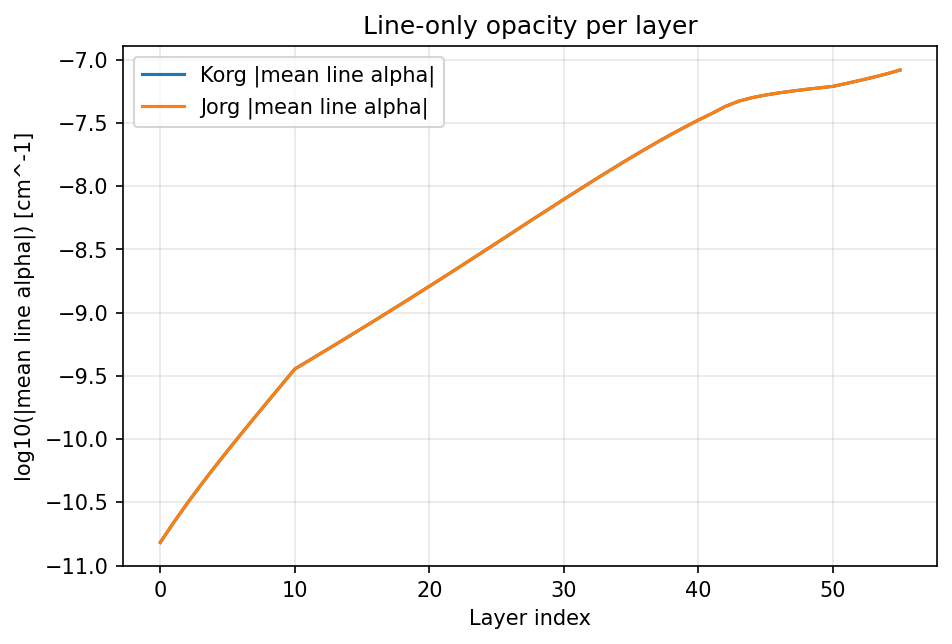

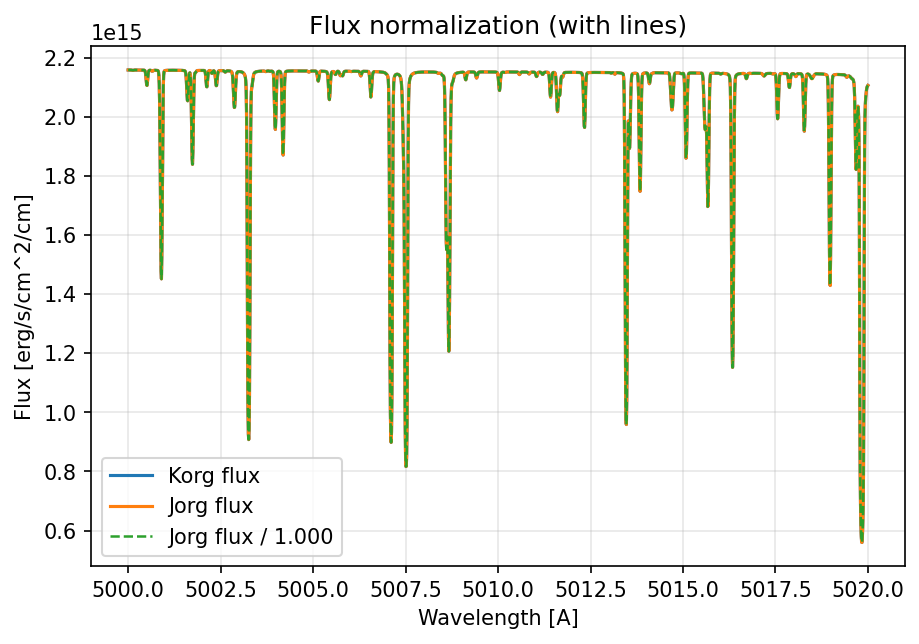

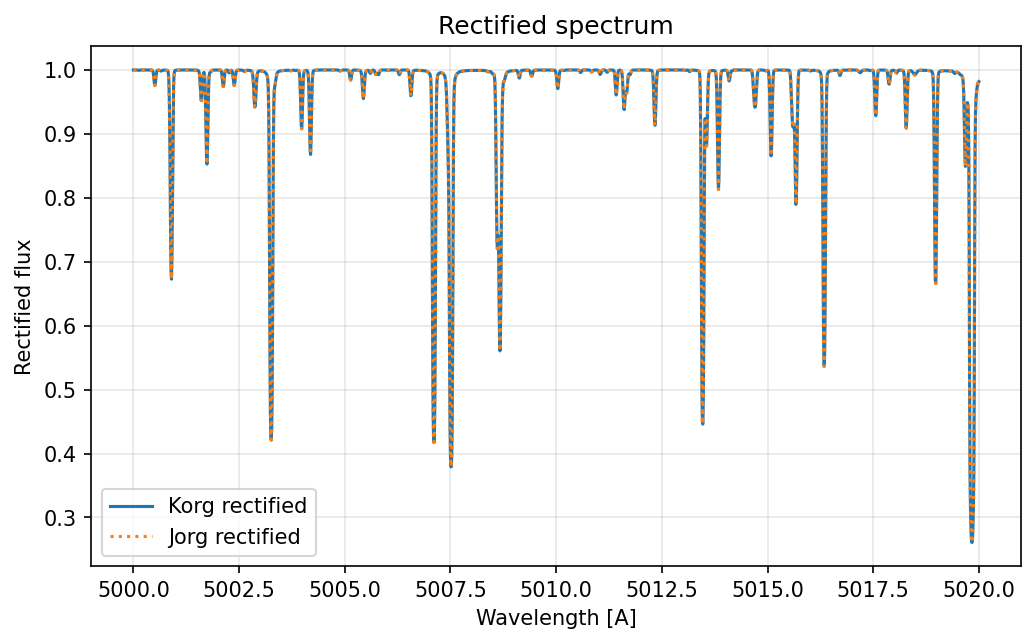

In [ ]:
# Plots
layer_idx = np.arange(n_layers)
eps = 1e-40

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.plot(layer_idx, np.log10(k_line_mean + eps), label='Korg |mean line alpha|', linewidth=1.5)
ax.plot(layer_idx, np.log10(j_line_mean + eps), label='Jorg |mean line alpha|', linewidth=1.5)
ax.set_xlabel('Layer index')
ax.set_ylabel('log10(|mean line alpha|) [cm^-1]')
ax.set_title('Line-only opacity per layer')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.plot(k_lines[:, 0], k_lines[:, 1], label='Korg flux', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 1], label='Jorg flux', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 1] / flux_scale, label=f'Jorg flux / {flux_scale:.3f}', linestyle='--', linewidth=1.2)
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/cm]')
ax.set_title('Flux normalization (with lines)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(k_lines[:, 0], k_lines[:, 3], label='Korg rectified', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 3], label='Jorg rectified', linewidth=1.5, ls=':')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Rectified flux')
ax.set_title('Rectified spectrum')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()